# 04 - Random Forest baseline (surface-feature-aware)

The first baseline (`03_baseline_model.ipynb`) only used latitude/longitude/depth/time - it
couldn't see any actual ocean conditions, so it was really a learned climatology. This
notebook is the fairer comparison point for the CNN: it uses the **real surface variables**
(SST, SSS, SLA, currents, winds) from the paired dataset built by `pairing.py`.

**Deliberate design choice:** for each sample, only the **center pixel** of the 5x5 patch is
used per channel - not the full patch. A Random Forest has no notion of spatial structure, so
feeding it 175 loose pixel values (7 channels x 5x5) would mostly be noise it can't organize
into "this is a front" or "this is an eddy edge." Using just the center point isolates the
question this baseline exists to answer: **does the CNN's use of surrounding spatial context
actually add value over the surface conditions at a single point?** If the CNN doesn't clearly
beat this baseline, that's a sign the spatial patch isn't earning its complexity yet.

**Also deliberately different from the first baseline:** this one predicts the full 15-depth
profile in a single multi-output regression (matching how the CNN's decoder works), rather
than treating each depth as a separate row with depth as an input feature.

In [1]:
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve().parent
PAIRS_DIR = PROJECT_ROOT / "data" / "processed" / "pairs"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

pair_files = sorted(PAIRS_DIR.glob("pairs_*.nc"))
if not pair_files:
    raise FileNotFoundError(f"No paired files found in {PAIRS_DIR} - run pairing.py first.")

print(f"Found {len(pair_files)} paired daily files")
print("First:", pair_files[0].name, " Last:", pair_files[-1].name)

Found 10 paired daily files
First: pairs_2021-01-01.nc  Last: pairs_2021-06-15.nc


## Load every daily pairs file and build the feature table

Each file only stores its date as a file-level attribute (not a per-sample coordinate), so the
date is attached to every sample as it's loaded, before everything gets concatenated together.

In [2]:
DATE_RE = re.compile(r"pairs_(\d{4}-\d{2}-\d{2})\.nc")

CENTER = 2  # index of the center pixel in a 5x5 patch (0-indexed)

all_features = []
all_profiles = []
all_valid = []
all_lat = []
all_lon = []
all_time = []

for path in pair_files:
    match = DATE_RE.search(path.name)
    date_str = match.group(1) if match else None

    with xr.open_dataset(path) as ds:
        n = ds.sizes["sample"]
        if n == 0:
            continue

        # Center pixel per channel -> (n, n_channels)
        center_vals = ds["patch"].isel(py=CENTER, px=CENTER).values

        all_features.append(center_vals)
        all_profiles.append(ds["profile"].values)
        all_valid.append(ds["valid_mask"].values)
        all_lat.append(ds["latitude"].values)
        all_lon.append(ds["longitude"].values)
        all_time.append(np.full(n, date_str))

        channel_names = list(ds["channel"].values)
        depth_values = ds["depth"].values

center_features = np.concatenate(all_features, axis=0)
profiles = np.concatenate(all_profiles, axis=0)
valid_mask = np.concatenate(all_valid, axis=0)
latitude = np.concatenate(all_lat, axis=0)
longitude = np.concatenate(all_lon, axis=0)
time_str = np.concatenate(all_time, axis=0)

print("Channels (feature order):", channel_names)
print("Depths:", depth_values)
print("Total samples:", center_features.shape[0])
print("Feature matrix shape:", center_features.shape)
print("Profile matrix shape:", profiles.shape)

Channels (feature order): [np.str_('sst'), np.str_('sss'), np.str_('sla'), np.str_('ugos'), np.str_('vgos'), np.str_('eastward_wind'), np.str_('northward_wind')]
Depths: [   0    5   10   20   30   50   75  100  125  150  200  300  500  700
 1000]
Total samples: 21279
Feature matrix shape: (21279, 7)
Profile matrix shape: (21279, 15)


In [3]:
# Only keep samples with a fully valid profile - pairing.py's default
# settings already enforce this (max_missing_depths=0), but this guards
# against re-running with looser settings later.
complete = valid_mask.all(axis=1)
print(f"Samples with a complete 15-depth profile: {complete.sum():,} / {len(complete):,}")

center_features = center_features[complete]
profiles = profiles[complete]
latitude = latitude[complete]
longitude = longitude[complete]
time_str = time_str[complete]

Samples with a complete 15-depth profile: 21,279 / 21,279


In [4]:
# Seasonal features, same construction as the first baseline, for consistency.
time_dt = pd.to_datetime(time_str)
day_of_year = time_dt.dayofyear.values
month = time_dt.month.values
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

X = np.column_stack([
    center_features,   # sst, sss, sla, ugos, vgos, eastward_wind, northward_wind
    latitude,
    longitude,
    day_of_year,
    month_sin,
    month_cos,
])

feature_names = channel_names + ["latitude", "longitude", "day_of_year", "month_sin", "month_cos"]
y = profiles  # (n_samples, 15) - multi-output target

print("Feature columns:", feature_names)
print("X shape:", X.shape, " y shape:", y.shape)

Feature columns: [np.str_('sst'), np.str_('sss'), np.str_('sla'), np.str_('ugos'), np.str_('vgos'), np.str_('eastward_wind'), np.str_('northward_wind'), 'latitude', 'longitude', 'day_of_year', 'month_sin', 'month_cos']
X shape: (21279, 12)  y shape: (21279, 15)


## Chronological split

Same principle as the first baseline: split by date range first, so no date appears in more
than one split.

In [5]:
unique_dates = np.sort(pd.unique(time_dt))
n_dates = len(unique_dates)

TRAIN_FRAC, VAL_FRAC = 0.70, 0.15

train_cutoff = unique_dates[int(n_dates * TRAIN_FRAC)]
val_cutoff = unique_dates[int(n_dates * (TRAIN_FRAC + VAL_FRAC))]

train_mask = time_dt < train_cutoff
val_mask = (time_dt >= train_cutoff) & (time_dt < val_cutoff)
test_mask = time_dt >= val_cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Train dates:", time_dt[train_mask].min(), "to", time_dt[train_mask].max())
print("Test dates: ", time_dt[test_mask].min(), "to", time_dt[test_mask].max())

Train: (14967, 12)  Val: (2100, 12)  Test: (4212, 12)
Train dates: 2021-01-01 00:00:00 to 2021-05-31 00:00:00
Test dates:  2021-06-10 00:00:00 to 2021-06-15 00:00:00


## Train

`RandomForestRegressor` natively supports multi-output regression - `y_train` with shape
`(n_samples, 15)` trains one forest that predicts all 15 depths together, no wrapper needed.

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=SEED,
)

rf.fit(X_train, y_train)
print("Training complete.")

# Quick validation-set check before committing to the full test evaluation below.
val_pred = rf.predict(X_val)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print(f"Validation RMSE (all depths combined): {val_rmse:.3f}")

Training complete.
Validation RMSE (all depths combined): 0.564


In [7]:
joblib.dump(rf, MODELS_DIR / "baseline_random_forest.pkl")
print("Model saved.")

Model saved.


## Evaluate on the test set - overall and by depth band

Same depth-band breakdown as the first baseline, so the two are directly comparable.

In [8]:
y_pred = rf.predict(X_test)

overall_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
overall_mae = mean_absolute_error(y_test, y_pred)
overall_r2 = r2_score(y_test, y_pred)

print("Random Forest Baseline Results (all depths combined)")
print("------------------------------------------------------")
print("RMSE:", overall_rmse)
print("MAE :", overall_mae)
print("R\u00b2  :", overall_r2)

Random Forest Baseline Results (all depths combined)
------------------------------------------------------
RMSE: 0.8491091983091399
MAE : 0.5458515985952862
R²  : 0.6461323904933132


In [9]:
depth_bins = [
    ("Shallow (0-100 m)", 0, 100),
    ("Thermocline (>100-300 m)", 100, 300),
    ("Deep (>300-1000 m)", 300, 1000),
]

print(f"{'Band':<25}{'RMSE':>10}{'MAE':>10}{'R\u00b2':>10}")
print("-" * 55)
band_results = []
for label, lo, hi in depth_bins:
    depth_idx = np.where((depth_values >= lo) & (depth_values <= hi))[0]
    band_rmse = np.sqrt(mean_squared_error(y_test[:, depth_idx], y_pred[:, depth_idx]))
    band_mae = mean_absolute_error(y_test[:, depth_idx], y_pred[:, depth_idx])
    band_r2 = r2_score(y_test[:, depth_idx], y_pred[:, depth_idx])
    band_results.append((label, band_rmse))
    print(f"{label:<25}{band_rmse:>10.3f}{band_mae:>10.3f}{band_r2:>10.3f}")

Band                           RMSE       MAE        R²
-------------------------------------------------------
Shallow (0-100 m)             0.798     0.534     0.579
Thermocline (>100-300 m)      1.184     0.805     0.550
Deep (>300-1000 m)            0.432     0.310     0.874


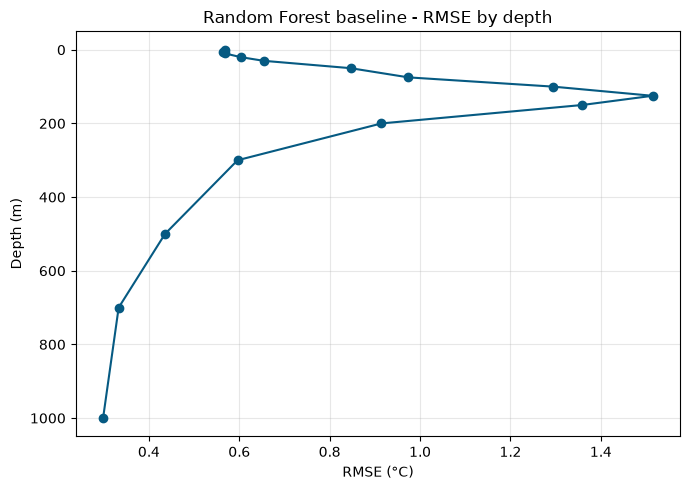

In [10]:
# Full per-depth RMSE curve - more informative than 3 bins alone, since the
# output is a genuine 15-point profile.
per_depth_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2, axis=0))

plt.figure(figsize=(7, 5))
plt.plot(per_depth_rmse, depth_values, marker="o", color="#065A82")
plt.gca().invert_yaxis()
plt.xlabel("RMSE (\u00b0C)")
plt.ylabel("Depth (m)")
plt.title("Random Forest baseline - RMSE by depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature importance

Which surface variable is the Random Forest actually relying on? Useful both as a sanity
check (SST should matter a lot near the surface) and as a talking point for the report.

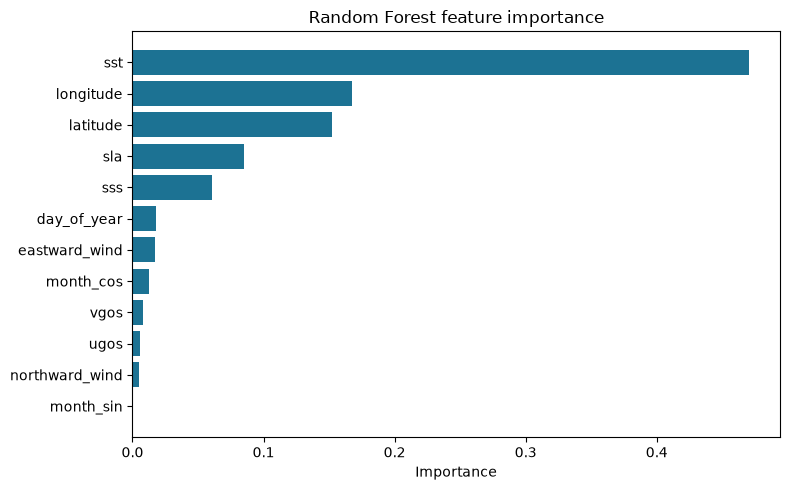

sst                0.4705
longitude          0.1671
latitude           0.1519
sla                0.0847
sss                0.0604
day_of_year        0.0176
eastward_wind      0.0171
month_cos          0.0123
vgos               0.0079
ugos               0.0054
northward_wind     0.0050
month_sin          0.0000


In [11]:
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in order], importances[order], color="#1C7293")
plt.xlabel("Importance")
plt.title("Random Forest feature importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

for i in order:
    print(f"{feature_names[i]:<18} {importances[i]:.4f}")

## Actual vs. predicted, at a shallow and a deep level

Same style of check as the first baseline's scatter plot, but split by depth this time - the
model's behavior at 10 m and at 700 m can look very different.

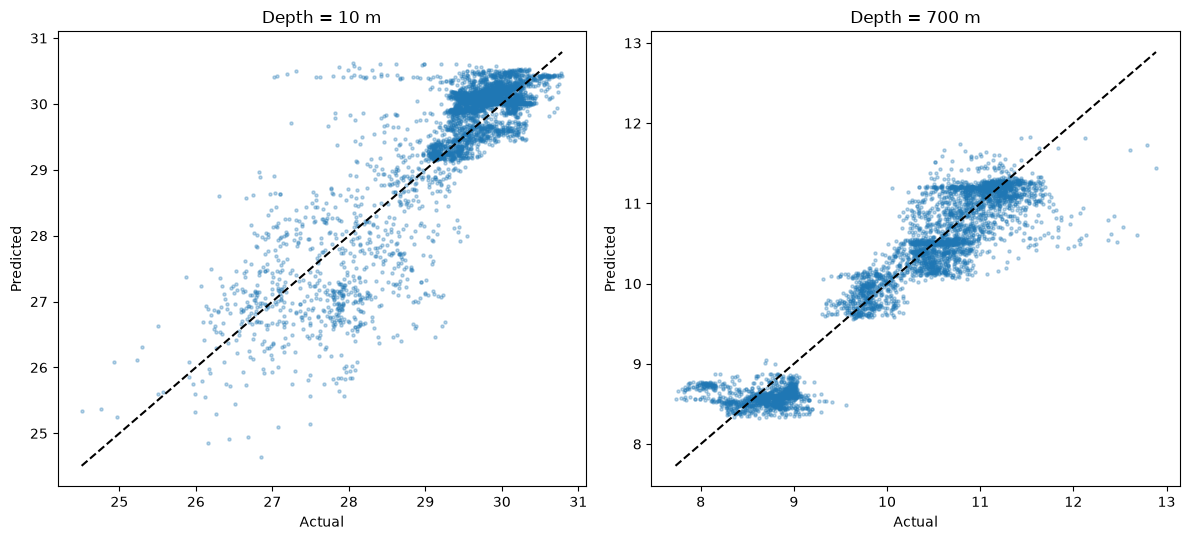

In [12]:
shallow_idx = np.argmin(np.abs(depth_values - 10))
deep_idx = np.argmin(np.abs(depth_values - 700))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, idx, label in zip(axes, [shallow_idx, deep_idx], [f"{depth_values[shallow_idx]:.0f} m", f"{depth_values[deep_idx]:.0f} m"]):
    ax.scatter(y_test[:, idx], y_pred[:, idx], s=5, alpha=0.3)
    lo = min(y_test[:, idx].min(), y_pred[:, idx].min())
    hi = max(y_test[:, idx].max(), y_pred[:, idx].max())
    ax.plot([lo, hi], [lo, hi], linestyle="--", color="black")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"Depth = {label}")

plt.tight_layout()
plt.show()

## Summary

This is now the number the CNN needs to beat - not the climatology baseline from
`03_baseline_model.ipynb`, since this one actually sees surface conditions. Record the
overall and per-band RMSE above before moving on to the CNN, so the comparison is on record.